In [2]:
import pandas as pd
import os

files = os.listdir("/content")
print(files)

['.config', '02_nav_history.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '01_fund_master.csv', '07_scheme_performance.csv', 'sample_data']


In [3]:
import pandas as pd

nav = pd.read_csv("/content/02_nav_history.csv")

print(nav.shape)
print(nav.head())
print(nav.columns.tolist())

(46000, 3)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']


In [4]:
# Make sure date is in date format
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return for each scheme
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

# Check the result
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


In [5]:
# Remove rows where daily return could not be calculated
returns = nav.dropna(subset=["daily_return"]).copy()

# Historical VaR at 95% confidence = 5th percentile
var_cvar = (
    returns.groupby("amfi_code")["daily_return"]
    .agg(
        VaR_95=lambda x: x.quantile(0.05),
        CVaR_95=lambda x: x[x <= x.quantile(0.05)].mean()
    )
    .reset_index()
)

# Convert to percentage for easier interpretation
var_cvar["VaR_95_pct"] = var_cvar["VaR_95"] * 100
var_cvar["CVaR_95_pct"] = var_cvar["CVaR_95"] * 100

print(var_cvar.head())
print("Number of schemes:", len(var_cvar))

   amfi_code    VaR_95   CVaR_95  VaR_95_pct  CVaR_95_pct
0     100016 -0.014364 -0.018060   -1.436364    -1.806021
1     100025 -0.003793 -0.004994   -0.379325    -0.499376
2     100033 -0.019034 -0.023456   -1.903354    -2.345576
3     101206 -0.013282 -0.017439   -1.328166    -1.743943
4     101207 -0.026021 -0.032459   -2.602125    -3.245906
Number of schemes: 40


In [6]:
fund_master = pd.read_csv("/content/01_fund_master.csv")

var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name", "category", "risk_category"]],
    on="amfi_code",
    how="left"
)

# Show the final VaR/CVaR report
var_cvar[
    ["amfi_code", "scheme_name", "category", "risk_category",
     "VaR_95_pct", "CVaR_95_pct"]
].head(10)

,amfi_code,scheme_name,category,risk_category,VaR_95_pct,CVaR_95_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Moderate,-1.436364,-1.806021
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Low,-0.379325,-0.499376
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-1.903354,-2.345576
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Moderate,-1.328166,-1.743943
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.602125,-3.245906
5,101208,ABSL Liquid Fund - Regular - Growth,Debt,Low,-0.026866,-0.042208
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Moderate,-1.261263,-1.549041
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,High,-1.922028,-2.325086
8,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,Moderately High,-1.523162,-1.941118
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,Moderate,-1.395405,-1.761858


In [7]:
# Keep only the useful report columns
var_cvar_report = var_cvar[
    ["amfi_code", "scheme_name", "category", "risk_category",
     "VaR_95_pct", "CVaR_95_pct"]
].copy()

# Save as CSV
var_cvar_report.to_csv(
    "/content/var_cvar_report.csv",
    index=False
)

print("Saved successfully!")
print(var_cvar_report.shape)

Saved successfully!
(40, 6)


In [8]:
import numpy as np

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate 90-day rolling Sharpe
nav["rolling_sharpe_90"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: (
        x.rolling(90).mean() /
        x.rolling(90).std()
    ) * np.sqrt(252)
)

)

print(nav[[
    "amfi_code",
    "date",
    "rolling_sharpe_90"
]].tail(10))

       amfi_code       date  rolling_sharpe_90
45990     149324 2026-05-18           2.008546
45991     149324 2026-05-19           1.790543
45992     149324 2026-05-20           2.064489
45993     149324 2026-05-21           2.138907
45994     149324 2026-05-22           1.615362
45995     149324 2026-05-25           2.042795
45996     149324 2026-05-26           2.064950
45997     149324 2026-05-27           1.952646
45998     149324 2026-05-28           1.406239
45999     149324 2026-05-29           1.262776


In [9]:
# Get 5 schemes with their names
key_funds = (
    nav[["amfi_code"]]
    .drop_duplicates()
    .merge(
        fund_master[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )
    .head(5)
)

print(key_funds)

   amfi_code                                        scheme_name
0     100016          HDFC Top 100 Fund - Regular Plan - Growth
1     100025       HDFC Short Term Debt Fund - Regular - Growth
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3     101206      ABSL Frontline Equity Fund - Regular - Growth
4     101207             ABSL Small Cap Fund - Regular - Growth


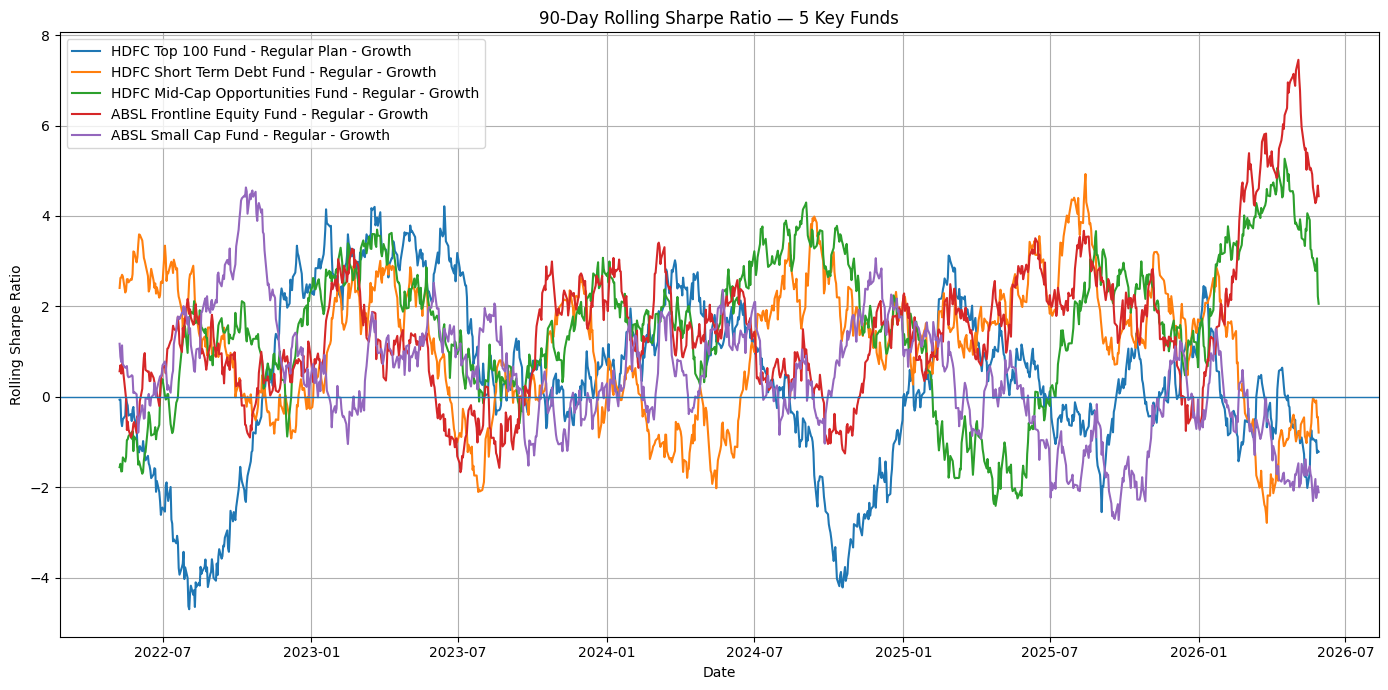

Chart saved as /content/rolling_sharpe_chart.png


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for _, row in key_funds.iterrows():
    fund_data = nav[nav["amfi_code"] == row["amfi_code"]]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=row["scheme_name"]
    )

plt.axhline(0, linewidth=1)
plt.title("90-Day Rolling Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save required deliverable
plt.savefig(
    "/content/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved as /content/rolling_sharpe_chart.png")

In [11]:
investor = pd.read_csv("/content/08_investor_transactions.csv")

print(investor.shape)
print(investor.columns.tolist())

(32778, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [12]:
# Convert transaction_date to proper datetime
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

# Create transaction year
investor["transaction_year"] = investor["transaction_date"].dt.year

print(investor[[
    "investor_id",
    "transaction_date",
    "transaction_year",
    "transaction_type",
    "amount_inr"
]].head())

print("\nYears available:", sorted(investor["transaction_year"].unique()))

  investor_id transaction_date  transaction_year transaction_type  amount_inr
0   INV003054       2024-01-01              2024              SIP        1834
1   INV002952       2024-01-01              2024       Redemption      392882
2   INV003420       2024-01-01              2024              SIP         912
3   INV003436       2024-01-01              2024              SIP        1102
4   INV004691       2024-01-01              2024          Lumpsum        8682

Years available: [np.int32(2024), np.int32(2025)]


In [13]:
first_transaction = (
    investor.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

print(first_transaction.head())
print("\nNumber of investors:", len(first_transaction))

  investor_id transaction_date  cohort_year
0   INV000001       2024-11-04         2024
1   INV000002       2024-03-29         2024
2   INV000003       2024-07-16         2024
3   INV000004       2024-03-16         2024
4   INV000005       2024-04-27         2024

Number of investors: 5000


In [14]:
investor = investor.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print(investor[[
    "investor_id",
    "cohort_year",
    "transaction_date",
    "transaction_type",
    "amount_inr"
]].head())

  investor_id  cohort_year transaction_date transaction_type  amount_inr
0   INV003054         2024       2024-01-01              SIP        1834
1   INV002952         2024       2024-01-01       Redemption      392882
2   INV003420         2024       2024-01-01              SIP         912
3   INV003436         2024       2024-01-01              SIP        1102
4   INV004691         2024       2024-01-01          Lumpsum        8682


In [15]:
# Calculate average SIP amount and total invested for each cohort

cohort_analysis = (
    investor.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

print(cohort_analysis)

   cohort_year  avg_sip_amount  total_invested  investors
0         2024   107422.541832      3491125187       4803
1         2025   109158.577061        30455243        197


In [16]:
# Count transactions by cohort and fund
cohort_fund = (
    investor.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

# Get the most preferred fund for each cohort
top_funds = (
    cohort_fund.loc[
        cohort_fund.groupby("cohort_year")["transaction_count"].idxmax()
    ]
    .reset_index(drop=True)
)

# Add fund names
top_funds = top_funds.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(top_funds)

   cohort_year  amfi_code  transaction_count  \
0         2024     148568                874   
1         2025     119599                 12   

                                         scheme_name  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [17]:
cohort_analysis = cohort_analysis.merge(
    top_funds[["cohort_year", "scheme_name", "transaction_count"]],
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.rename(
    columns={
        "scheme_name": "top_fund_preference",
        "transaction_count": "top_fund_transactions"
    }
)

print(cohort_analysis)

   cohort_year  avg_sip_amount  total_invested  investors  \
0         2024   107422.541832      3491125187       4803   
1         2025   109158.577061        30455243        197   

                                 top_fund_preference  top_fund_transactions  
0  Mirae Asset Emerging Bluechip Fund - Regular -...                    874  
1          SBI Small Cap Fund - Direct Plan - Growth                     12  


In [18]:
cohort_analysis.to_csv(
    "/content/investor_cohort_analysis.csv",
    index=False
)

print("Saved:", "/content/investor_cohort_analysis.csv")

Saved: /content/investor_cohort_analysis.csv


In [19]:
sip = investor[
    investor["transaction_type"].astype(str).str.upper().str.contains("SIP", na=False)
].copy()

sip = sip.sort_values(["investor_id", "transaction_date"])

print("Total SIP transactions:", len(sip))
print("Unique SIP investors:", sip["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [20]:
sip_counts = (
    sip.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
].copy()

print("Investors with 6+ SIP transactions:", len(eligible_investors))
print(eligible_investors.head())

Investors with 6+ SIP transactions: 1362
   investor_id  sip_count
3    INV000004          6
7    INV000008          6
9    INV000010          6
10   INV000011          7
11   INV000012          8


In [21]:
# Keep only eligible investors
sip_eligible = sip[
    sip["investor_id"].isin(eligible_investors["investor_id"])
].copy()

# Calculate gap in days between consecutive SIP transactions
sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

print(sip_eligible[
    ["investor_id", "transaction_date", "gap_days"]
].head(15))

      investor_id transaction_date  gap_days
4773    INV000004       2024-03-16       NaN
6418    INV000004       2024-04-11      26.0
8271    INV000004       2024-05-09      28.0
12003   INV000004       2024-07-07      59.0
28749   INV000004       2025-03-29     265.0
31897   INV000004       2025-05-17      49.0
9329    INV000008       2024-05-27       NaN
11113   INV000008       2024-06-23      27.0
21549   INV000008       2024-12-05     165.0
24389   INV000008       2025-01-18      44.0
25907   INV000008       2025-02-11      24.0
31674   INV000008       2025-05-14      92.0
6467    INV000010       2024-04-11       NaN
15384   INV000010       2024-08-28     139.0
21247   INV000010       2024-12-01      95.0


In [22]:
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_count=("sip_count", "first") if "sip_count" in sip_eligible.columns else ("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

sip_continuity["status"] = sip_continuity["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

print(sip_continuity.head(10))
print("\nStatus counts:")
print(sip_continuity["status"].value_counts())

  investor_id  sip_count  avg_gap_days  max_gap_days   status
0   INV000004          6     85.400000         265.0  At-Risk
1   INV000008          6     70.400000         165.0  At-Risk
2   INV000010          6     64.800000         139.0  At-Risk
3   INV000011          7     40.166667         125.0  At-Risk
4   INV000012          8     57.000000         132.0  At-Risk
5   INV000013          7     55.333333         104.0  At-Risk
6   INV000014          7     75.333333         128.0  At-Risk
7   INV000023          8     58.571429         115.0  At-Risk
8   INV000028          6     93.600000         238.0  At-Risk
9   INV000029          7     60.666667          96.0  At-Risk

Status counts:
status
At-Risk    1332
Regular      30
Name: count, dtype: int64


In [23]:
total_eligible = len(sip_continuity)

regular_count = (sip_continuity["status"] == "Regular").sum()
at_risk_count = (sip_continuity["status"] == "At-Risk").sum()

continuity_rate = (regular_count / total_eligible) * 100
at_risk_rate = (at_risk_count / total_eligible) * 100

print(f"Total eligible investors: {total_eligible}")
print(f"Regular: {regular_count} ({continuity_rate:.2f}%)")
print(f"At-Risk: {at_risk_count} ({at_risk_rate:.2f}%)")

Total eligible investors: 1362
Regular: 30 (2.20%)
At-Risk: 1332 (97.80%)


In [24]:


sip_continuity.to_csv(
    "/content/sip_continuity_analysis.csv",
    index=False
)

print("Saved:", "/content/sip_continuity_analysis.csv")

Saved: /content/sip_continuity_analysis.csv


In [25]:
performance = pd.read_csv("/content/07_scheme_performance.csv")

print(performance.shape)
print(performance.columns.tolist())

(40, 19)
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [26]:
print(performance["risk_grade"].value_counts())

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [27]:
# Map detailed risk grades into the 3 requested risk appetites
def map_risk_appetite(risk_grade):
    if risk_grade == "Low":
        return "Low"
    elif risk_grade == "Moderate":
        return "Moderate"
    else:
        return "High"


performance["risk_appetite"] = performance["risk_grade"].apply(
    map_risk_appetite
)

# Recommender function
def recommend_funds(risk_appetite):
    result = (
        performance[
            performance["risk_appetite"].str.lower()
            == risk_appetite.lower()
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )

    return result[
        ["scheme_name", "risk_grade", "sharpe_ratio",
         "return_1yr_pct", "return_3yr_pct", "max_drawdown_pct"]
    ]

# Test the recommender
print(recommend_funds("Moderate"))

                                      scheme_name risk_grade  sharpe_ratio  \
5       HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06   
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06   
11      ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03   

    return_1yr_pct  return_3yr_pct  max_drawdown_pct  
5            10.94           14.84            -17.41  
34           15.12           14.81            -17.07  
11           14.12           14.41            -26.59  


In [28]:
for risk in ["Low", "Moderate", "High"]:
    print(f"\n===== {risk.upper()} RISK =====")
    print(recommend_funds(risk).to_string(index=False))


===== LOW RISK =====
                             scheme_name risk_grade  sharpe_ratio  return_1yr_pct  return_3yr_pct  max_drawdown_pct
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            8.89            7.68             -2.62
    Kotak Liquid Fund - Regular - Growth        Low          6.18            4.26            6.18             -3.81
     ABSL Liquid Fund - Regular - Growth        Low          5.14            6.18            5.14             -3.66

===== MODERATE RISK =====
                                  scheme_name risk_grade  sharpe_ratio  return_1yr_pct  return_3yr_pct  max_drawdown_pct
    HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           10.94           14.84            -17.41
Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           15.12           14.81            -17.07
    ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03           14.12           14.41            -26.59

==

In [29]:
recommender_code = '''
import pandas as pd

# Load fund performance data
performance = pd.read_csv("07_scheme_performance.csv")

# Map detailed risk grades to requested risk appetites
def map_risk_appetite(risk_grade):
    if risk_grade == "Low":
        return "Low"
    elif risk_grade == "Moderate":
        return "Moderate"
    else:
        return "High"

performance["risk_appetite"] = performance["risk_grade"].apply(
    map_risk_appetite
)

# Fund recommender
def recommend_funds(risk_appetite):
    result = (
        performance[
            performance["risk_appetite"].str.lower()
            == risk_appetite.lower()
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )

    return result[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_1yr_pct",
            "return_3yr_pct",
            "max_drawdown_pct"
        ]
    ]

# Example
if __name__ == "__main__":
    risk = input("Enter risk appetite (Low / Moderate / High): ")
    print(recommend_funds(risk).to_string(index=False))
'''

with open("/content/recommender.py", "w") as f:
    f.write(recommender_code)

print("recommender.py created successfully!")

recommender.py created successfully!


In [30]:
holdings = pd.read_csv("/content/09_portfolio_holdings.csv")

print(holdings.shape)
print(holdings.columns.tolist())

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [31]:
# Convert weight percentage to decimal
holdings["weight_decimal"] = holdings["weight_pct"] / 100

# Calculate HHI for each fund
hhi = (
    holdings.groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

# Convert to the standard 0–10,000 HHI scale
hhi["HHI_10000"] = hhi["HHI"] * 10000

print(hhi.head())
print("\nNumber of funds:", len(hhi))

   amfi_code       HHI  HHI_10000
0     100016  0.139534  1395.3386
1     100033  0.147592  1475.9226
2     101206  0.129332  1293.3173
3     101207  0.200700  2007.0043
4     102885  0.174709  1747.0902

Number of funds: 34


In [32]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi_ranked = hhi.sort_values(
    "HHI_10000",
    ascending=False
).reset_index(drop=True)

print(
    hhi_ranked[
        ["scheme_name", "category", "HHI_10000"]
    ].head(10).to_string(index=False)
)

                                          scheme_name category  HHI_10000
                Axis Bluechip Fund - Regular - Growth   Equity  2064.4767
               ABSL Small Cap Fund - Regular - Growth   Equity  2007.0043
            SBI Small Cap Fund - Direct Plan - Growth   Equity  1747.5096
           UTI Nifty 50 Index Fund - Regular - Growth   Equity  1747.0902
       Nippon India Large Cap Fund - Regular - Growth   Equity  1682.9820
Mirae Asset Emerging Bluechip Fund - Regular - Growth   Equity  1679.2973
             ICICI Pru Midcap Fund - Regular - Growth   Equity  1575.7036
    ICICI Pru Value Discovery Fund - Regular - Growth   Equity  1537.9360
    HDFC Mid-Cap Opportunities Fund - Direct - Growth   Equity  1524.1398
               Kotak Bluechip Fund - Regular - Growth   Equity  1496.8035


In [33]:
hhi_ranked.to_csv(
    "/content/sector_hhi_analysis.csv",
    index=False
)

print("Saved:", "/content/sector_hhi_analysis.csv")

Saved: /content/sector_hhi_analysis.csv


# Advanced Analytics — Key Insights

### 1. Risk Analysis
Historical VaR and CVaR were calculated for all 40 mutual fund schemes. Funds with more negative VaR and CVaR values experienced greater downside risk in the historical daily-return distribution.

### 2. Rolling Sharpe Ratio
The 90-day rolling Sharpe ratio was calculated for 5 key funds to evaluate changes in risk-adjusted performance over time using 252 trading days for annualization.

### 3. Investor Cohort Analysis
Investors were grouped according to their first transaction year. The analysis compares investor count, total invested amount, average transaction amount, and the most preferred fund across different cohorts.

### 4. SIP Continuity Analysis
Among 1,362 investors with at least 6 SIP transactions, 1,332 (97.80%) were classified as At-Risk because their average gap between SIP transactions exceeded 35 days. Only 30 investors (2.20%) were classified as Regular.

### 5. Portfolio Concentration
HHI analysis identified Axis Bluechip Fund as the most concentrated analyzed equity fund, with an HHI of 2,064.48, followed by ABSL Small Cap Fund with an HHI of 2,007.00.